In [287]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [288]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('wb', 0e9*2*pi, is_excitation=True)
# sim.add_param('sqrtkb', np.sqrt(1e7 * 2 * np.pi)) # in MHz
sim.add_param('g3', 10e6 * 2 * np.pi)
sim.add_param('K', 0.00e6 * 2 * np.pi)


sim.add_paramsweep('amplG', 0, 0.2, 101)  # 18 - gain
sim.add_param('wG', 1e6 * 2 * np.pi)  # 19
sim.add_param('rampG', 5e-9)  # 14
sim.add_param('startG', 20e-9)  # 21
sim.add_param('stopG', 50e-9)  # 22
sim.add_param('phaseG', 0)  # 23
sim.add_param('IC', 1)

sim.add_EOM('s1', '0', IC_str='amplG')

# sim.add_EOM('b', '-1j*wb*b - (sqrtkb**2/2)*b + 1j*g3*conjugate(b)*s1 - 1j*b*K*abs(b)**2',IC_str='IC')
sim.add_EOM('b', '- 1j*b*K*abs(b)**2 - 1j*g3*conjugate(b)*s1',IC_str='IC')
sim.add_EOM('bb', '- 4j*bb*K*abs(b)**2 - 4j*bb*K - g3*s1 - 4j*g3*s1*abs(b)**2', IC_str='IC**2')
sim.add_EOM('nb', '1j*g3*bb*s1 - 1j*g3*conjugate(bb)*s1',IC_str='IC**2')

sim.set_solve_type('all')

sim.specify_time(t_f=200e-9, pts=2000)

sim.validate()

Recent change to specify_time(), check implementation
Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


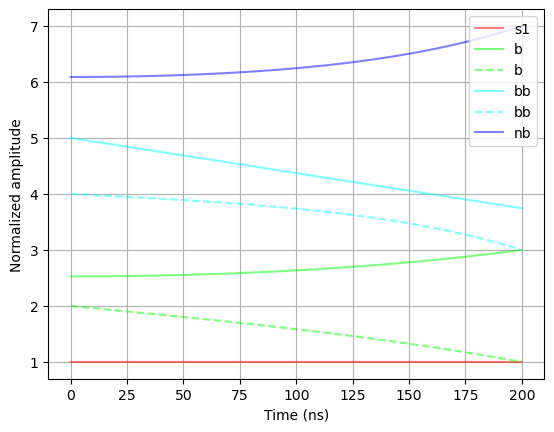

In [289]:
x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(np.abs(x[0,:])),color=(1,0,0,0.5),label='s1')
plt.plot(t*1e9, x[2,:]/np.max(np.abs(x[2,:]))+2,color=(0,1,0,0.5),label='b')
plt.plot(t*1e9, x[3,:]/np.max(np.abs(x[3,:]))+2,'--',color=(0,1,0,0.5),label='b')
plt.plot(t*1e9, x[4,:]/np.max(np.abs(x[4,:]))+4,color=(0,1,1,0.5),label='bb')
plt.plot(t*1e9, x[5,:]/np.max(np.abs(x[5,:]))+4,'--',color=(0,1,1,0.5),label='bb')
plt.plot(t*1e9, x[6,:]/np.max(np.abs(x[6,:]))+6,color=(0,0,1,0.5),label='nb')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()
plt.show()

In [283]:
x, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:01<00:00, 1664.24it/s]

 
...finished GPU solve!


In [284]:
xd = x.copy()
td = t.copy()

In [285]:
b = x[2,:]+1j*x[3,:]
bb = x[4,:]+1j*x[5,:]
nb = x[6,:]+1j*x[7,:]

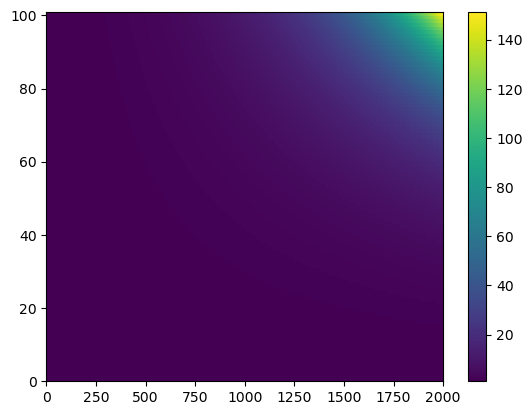

In [286]:
plt.pcolor(np.abs(nb))
plt.colorbar()
plt.show()

In [274]:
np.shape(b)

(101, 2000)

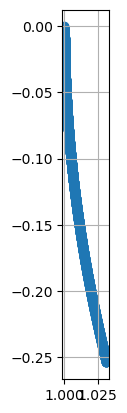

In [275]:
i = 10
plt.scatter(np.real(b[i,:]), np.imag(b[i,:]))
plt.gca().set_aspect('equal')
plt.grid()
plt.show()

In [276]:
def plot_Qfunc(a, aa, na):

    ad = np.conjugate(a)
    adad = np.conjugate(aa)
    sxx = 1/2 + 1/2*( (aa - a*a) + 2*(na - ad*a) + (adad - ad*ad))
    syy = 1/2 - 1/2*( (aa - a*a) - 2*(na - ad*a) + (adad - ad*ad))
    sxy = np.imag(1/2*((aa - a*a) - (adad - ad*ad)))
    covar =  np.real(np.array([[sxx, sxy], [sxy, syy]]))

    print(covar)

    phi = np.linspace(0, 2*np.pi, 101)
    
    print(np.linalg.eig(covar))
    
    theta = -np.angle(np.linalg.eig(covar)[1][:,1][0]+1j*np.linalg.eig(covar)[1][:,1][1])
    Smajor = np.sort(np.linalg.eig(covar)[0])[1]
    Sminor = np.sort(np.linalg.eig(covar)[0])[0]
    
    x1 = np.sqrt(Smajor)*np.cos(phi)*2
    y1 = np.sqrt(Sminor)*np.sin(phi)*2
    
    x2 = x1*np.cos(theta) + y1*np.sin(theta) + np.real(a)
    y2 = -x1*np.sin(theta) + y1*np.cos(theta) + np.imag(a)
    
    plt.plot(x2,y2)
    plt.xlim([-7,7])
    plt.ylim([-7,7])
    plt.gca().set_aspect('equal')
    plt.grid()
    plt.show()


(1.032069305733779-0.2552783810623325j) (0.7474159549599984-1.0538599260474333j) (1.2606682073512079-9.644743707385801e-20j)
[[ 0.37775006 -0.52692996]
 [-0.52692996  0.88291815]]
EigResult(eigenvalues=array([0.04599355, 1.21467466]), eigenvectors=array([[-0.84624313,  0.53279693],
       [-0.53279693, -0.84624313]]))


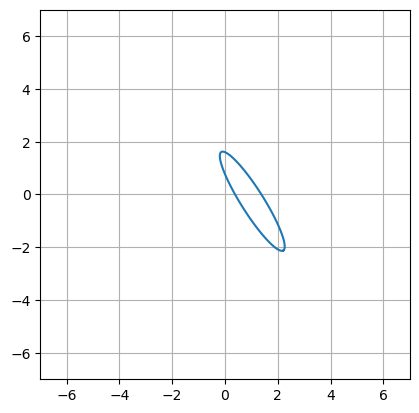

In [279]:
i = -1
j = 200
print(b[i,j], bb[i,j], nb[i,j])
plot_Qfunc(b[i,j], bb[i,j], nb[i,j])

In [73]:
bb[10,-1]

np.complex128(-0.5072310066804783-69.34363647808179j)